# Notebook 01：数据下载与股票池构建

本 Notebook 串联 `src/data/universe.py` 的原始数据下载流程与 `src/data/preprocess.py` 的预处理流程。导入、参数、函数调用和结果检查被拆成独立模块，建议按顺序逐个运行，以便在发生错误时快速定位。

默认关闭下载和预处理开关，避免执行“全部运行”时意外发起大量 Tushare 请求。确认参数后，先开启并运行下载模块，再开启并运行预处理模块。

## 模块 1：定位项目目录

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """从当前目录向上查找包含 src/data/universe.py 的项目根目录。"""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data" / "universe.py").is_file():
            return candidate
    raise FileNotFoundError("无法定位项目根目录，请从项目目录或 notebooks 目录启动 Notebook。")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"项目根目录：{PROJECT_ROOT}")

项目根目录：/Users/mac/Desktop/a-share-multifactor


## 模块 2：导入函数

本模块只负责导入依赖和项目函数，不下载或处理数据。若这里报错，应先检查项目路径和依赖安装。

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data.universe import (
    DEFAULT_RAW_DIRECTORY,
    DownloadConfig,
    run_download_pipeline,
)
from src.data.preprocess import (
    DEFAULT_PROCESSED_DIRECTORY,
    UniverseConfig,
    run_preprocess_pipeline,
)

print("项目函数导入成功。")

项目函数导入成功。


## 模块 3：配置工作流参数

下载区间比正式研究区间提前一年，为上市交易日计数、TTM 财务指标和研究初期数据匹配保留缓冲。`run_download_pipeline` 还会自动将财务报表下载起点再向前扩展一年。

In [3]:
# 先保持为 False；确认日期、Tushare 权限和本地存储空间后再逐步开启。
RUN_DOWNLOAD = False
RUN_PREPROCESS = True

DOWNLOAD_START = "20170101"
STUDY_START = "20180101"
STUDY_END = "20251231"

RAW_DIRECTORY = DEFAULT_RAW_DIRECTORY
PROCESSED_DIRECTORY = DEFAULT_PROCESSED_DIRECTORY

download_config = DownloadConfig(
    start_date=DOWNLOAD_START,
    end_date=STUDY_END,
)
preprocess_config = UniverseConfig(
    study_start=STUDY_START,
    study_end=STUDY_END,
    min_listing_trading_days=120,
    liquidity_quantile=None,  # 如需排除成交额最低 5%，可改为 0.05。
)

In [4]:
env_path = PROJECT_ROOT / ".env"
config_summary = pd.Series(
    {
        "Tushare 配置文件存在": env_path.is_file(),
        "原始数据目录": str(RAW_DIRECTORY),
        "处理后数据目录": str(PROCESSED_DIRECTORY),
        "下载区间": f"{DOWNLOAD_START} - {STUDY_END}",
        "研究区间": f"{STUDY_START} - {STUDY_END}",
        "下载开关": RUN_DOWNLOAD,
        "预处理开关": RUN_PREPROCESS,
    },
    name="当前配置",
)
display(config_summary.to_frame())

if not env_path.is_file():
    raise FileNotFoundError(f"未找到 {env_path}，请在项目根目录创建 .env 并设置 TUSHARE_TOKEN。")

,当前配置
Tushare 配置文件存在,True
原始数据目录,/Users/mac/Desktop/a-share-multifactor/data/raw
处理后数据目录,/Users/mac/Desktop/a-share-multifactor/data/pr...
下载区间,20170101 - 20251231
研究区间,20180101 - 20251231
下载开关,False
预处理开关,True


## 模块 4：调用原始数据下载流程

将 `RUN_DOWNLOAD` 改为 `True` 后运行本单元。该函数会从项目根目录的 `.env` 读取 `TUSHARE_TOKEN`，并把 Tushare 原始数据写入 `data/raw`。日频分区已存在时会跳过，可用于断点续跑。

In [7]:
download_outputs = None

if RUN_DOWNLOAD:
    download_outputs = run_download_pipeline(
        download_config,
        raw_directory=RAW_DIRECTORY,
    )
else:
    print("未执行下载：如需下载，请将 RUN_DOWNLOAD 改为 True 后重新运行本单元。")

Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试


## 模块 5：检查原始数据下载结果

本模块不调用 Tushare，只检查下载函数返回的路径以及 `data/raw` 中各数据集的存在情况。

In [8]:
if download_outputs is None:
    print("当前会话尚未执行下载函数；下面仍会检查本地已有的原始数据。")
else:
    returned_paths = pd.DataFrame(
        [
            {"数据集": name, "路径": str(path), "存在": path.exists()}
            for name, path in download_outputs.items()
        ]
    )
    display(returned_paths)

,数据集,路径,存在
0,trade_calendar,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
1,stock_basic,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
2,daily_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
3,adj_factor_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
4,daily_basic_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
5,stk_limit_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
6,suspend_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
7,stock_st_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
8,income,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
9,balancesheet,/Users/mac/Desktop/a-share-multifactor/data/ra...,True


In [9]:
raw_files = {
    "交易日历": RAW_DIRECTORY / "trade_calendar.parquet",
    "股票基础信息": RAW_DIRECTORY / "stock_basic.parquet",
    "申万行业历史成分": RAW_DIRECTORY / "sw_industry_membership.parquet",
    "财务下载清单": RAW_DIRECTORY / "financial_download_manifest.parquet",
}
raw_partitions = {
    "日线行情": (RAW_DIRECTORY / "daily", "trade_date=*.parquet"),
    "复权因子": (RAW_DIRECTORY / "adj_factor", "trade_date=*.parquet"),
    "每日指标": (RAW_DIRECTORY / "daily_basic", "trade_date=*.parquet"),
    "涨跌停价格": (RAW_DIRECTORY / "stk_limit", "trade_date=*.parquet"),
    "停牌记录": (RAW_DIRECTORY / "suspend_d", "trade_date=*.parquet"),
    "ST 记录": (RAW_DIRECTORY / "stock_st", "trade_date=*.parquet"),
    "利润表": (RAW_DIRECTORY / "income", "ts_code=*.parquet"),
    "资产负债表": (RAW_DIRECTORY / "balancesheet", "ts_code=*.parquet"),
}

raw_file_status = [
    {"数据集": name, "路径": str(path), "存在": path.is_file(), "分区数": None}
    for name, path in raw_files.items()
]
raw_partition_status = [
    {
        "数据集": name,
        "路径": str(path),
        "存在": path.is_dir(),
        "分区数": len(list(path.glob(pattern))) if path.is_dir() else 0,
    }
    for name, (path, pattern) in raw_partitions.items()
]
raw_status = pd.DataFrame(raw_file_status + raw_partition_status)
display(raw_status)

if not raw_status["存在"].all():
    print("警告：部分原始数据不存在。请先完成下载，再运行预处理模块。")

,数据集,路径,存在,分区数
0,交易日历,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
1,股票基础信息,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
2,利润表,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
3,资产负债表,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
4,申万行业历史成分,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
5,日线行情,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
6,复权因子,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
7,每日指标,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
8,涨跌停价格,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
9,停牌记录,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0


## 文件内容

### trade_calendar.parquet

时间范围为 2017-01-03 至 2025-12-31。它在预处理中用于：

- 确定每个自然月的最后一个交易日，由此**生成月末调仓日**；
- 计算股票上市后的交易日数量，以判断是否达到上市满 120 个交易日的要求。

| 字段 | 含义 |
|---|---|
| `exchange` | 交易所，这里使用 SSE 交易日历 |
| `cal_date` | 日历日期 |
| `is_open` | 是否开市 |
| `pretrade_date` | 上一个交易日 |

### stock_basic.parquet

股票基础信息表，每只股票通常对应一行。它在预处理中用于：

- 按照研究内容选择特定交易所的人民币股票；
- 判断股票在某个历史调仓日是否已经上市或已经退市，并计算上市交易日数。

| 字段 | 含义 |
|---|---|
| `ts_code` | Tushare 股票代码，如 `000001.SZ` |
| `symbol` | 不带交易所后缀的股票代码 |
| `name` | 当前股票简称 |
| `market` | 主板、创业板、科创板等市场类型 |
| `exchange` | SSE、SZSE 等交易所 |
| `curr_type` | 交易币种 |
| `list_status` | 上市状态 |
| `list_date` | 上市日期 |
| `delist_date` | 退市日期，仍上市时为空 |

### income/ts_code=*.parquet

利润表数据，报告期从 2008-12-31 延伸到 2025-09-30. 它用于计算 revenue_ttm, net_profit_ttm, gross_profit_ttm，并且也是 point-in-time 匹配所必需的。

| 字段 | 含义 |
|---|---|
| `ts_code` | 股票代码 |
| `ann_date` | 公告日期 |
| `f_ann_date` | 实际公告或修订版本日期 |
| `end_date` | 财报报告期 |
| `report_type` | 报告类型 |
| `comp_type` | 公司类型 |
| `revenue` | 营业收入 |
| `oper_cost` | 营业成本 |
| `n_income_attr_p` | 归属于母公司股东的净利润 |
| `update_flag` | 是否为更新版本 |

### balancesheet/ts_code=*.parquet

资产负债表按股票代码分区保存，与 income 目录中的利润表分区作用类似。

| 字段 | 含义 |
|---|---|
| `ts_code` | 股票代码 |
| `ann_date` | 公告日期 |
| `f_ann_date` | 实际公告或修订日期 |
| `end_date` | 财报报告期 |
| `report_type` | 报告类型 |
| `comp_type` | 公司类型 |
| `total_assets` | 总资产 |
| `total_hldr_eqy_exc_min_int` | 不含少数股东权益的股东权益 |
| `total_hldr_eqy_inc_min_int` | 包含少数股东权益的股东权益 |
| `update_flag` | 是否为更新版本 |

### sw_industry_membership.parquet

申万行业历史成分表，包含一级、二级和三级行业分类。申万行业是申万宏源研究制定的一套上市公司行业分类标准，主要用于证券研究、指数编制和量化分析。它不是交易所的官方监管分类，而是一套更适合投资研究的行业体系。预处理时使用 in_date <= 调仓日 <= out_date 来匹配当时的申万一级行业，避免使用当前行业分类回填历史。

| 字段 | 含义 |
|---|---|
| `l1_code`、`l1_name` | 申万一级行业代码和名称 |
| `l2_code`、`l2_name` | 申万二级行业代码和名称 |
| `l3_code`、`l3_name` | 申万三级行业代码和名称 |
| `ts_code` | 股票代码 |
| `name` | 股票名称 |
| `in_date` | 纳入该行业的日期 |
| `out_date` | 调出该行业的日期；为空表示仍有效 |
| `is_new` | 是否为当前有效行业记录 |

## 模块 6：调用预处理流程

将 `RUN_PREPROCESS` 改为 `True` 后运行本单元。`run_preprocess_pipeline` 只读取 `data/raw`：先构建日频行情事实表，再建立“月末调仓日 × 股票”的骨架并按上市区间筛选，随后左连接月末行情、ST、停牌、point-in-time 财务和历史行业，最后输出两个 Parquet 文件到 `data/processed`。没有月末行情的理论上市股票仍会保留，并由 `has_price_record` 标记。

In [5]:
processed_outputs = None

if RUN_PREPROCESS:
    processed_outputs = run_preprocess_pipeline(
        preprocess_config,
        raw_directory=RAW_DIRECTORY,
        processed_directory=PROCESSED_DIRECTORY,
    )
else:
    print("未执行预处理：确认原始数据完整后，将 RUN_PREPROCESS 改为 True 并重新运行本单元。")

/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:133: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat((pd.read_parquet(path) for path in paths), ignore_index=True)
/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:846: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly["has_price_record"].fillna(False).astype(bool)
/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:941: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change

## 模块 7：检查预处理输出路径

本模块只检查预处理函数的输出文件，不重复执行预处理。

In [6]:
if processed_outputs is None:
    price_path = PROCESSED_DIRECTORY / "price_daily.parquet"
    universe_path = PROCESSED_DIRECTORY / "universe_monthly.parquet"
    print("当前会话尚未执行预处理函数；下面将检查本地已有的标准输出路径。")
else:
    price_path, universe_path = processed_outputs

processed_status = pd.DataFrame(
    [
        {"数据集": "日频价格面板", "路径": str(price_path), "存在": price_path.is_file()},
        {"数据集": "月度股票池", "路径": str(universe_path), "存在": universe_path.is_file()},
    ]
)
display(processed_status)

if not processed_status["存在"].all():
    print("警告：处理后文件不完整。请检查预处理模块的错误输出。")

,数据集,路径,存在
0,日频价格面板,/Users/mac/Desktop/a-share-multifactor/data/pr...,True
1,月度股票池,/Users/mac/Desktop/a-share-multifactor/data/pr...,True


## 模块 8：读取处理后数据

读取操作与预处理调用分开；因此读取失败时，可以区分是文件未生成、Parquet 引擎问题，还是后续质量检查问题。

In [7]:
price_daily = pd.read_parquet(price_path) if price_path.is_file() else None
universe_monthly = pd.read_parquet(universe_path) if universe_path.is_file() else None

if price_daily is None or universe_monthly is None:
    print("尚未加载完整的处理后数据；请先运行下载和预处理模块。")
else:
    print("两个处理后数据集均已成功读取。")

两个处理后数据集均已成功读取。


## 模块 9：字段、主键和覆盖区间检查

当前实现中，财报所属期字段保留为 `end_date`，对应 README 中的 `report_period`。若缺少最低需要字段或出现重复主键，本单元会直接报错。

In [8]:
required_price_columns = {
    "date", "stock_code", "open", "high", "low", "close",
    "prev_close", "volume", "amount", "adj_factor",
}
required_universe_columns = {
    "date", "stock_code", "list_date", "delist_date", "is_st",
    "is_suspended", "industry", "market_cap", "total_assets",
    "total_equity", "net_profit_ttm", "revenue_ttm",
    "gross_profit_ttm", "end_date", "announcement_date",
    "financial_available_date", "report_age_days",
    "announcement_age_days", "is_gross_profit_applicable",
    "has_gross_profit_data", "has_gp_factor_data",
    "has_price_record", "is_buyable", "has_core_data", "is_eligible",
}

quality_summary = None
if price_daily is not None and universe_monthly is not None:
    missing_price_columns = sorted(required_price_columns - set(price_daily.columns))
    missing_universe_columns = sorted(required_universe_columns - set(universe_monthly.columns))
    if missing_price_columns or missing_universe_columns:
        raise KeyError(
            f"price_daily 缺失字段：{missing_price_columns}；"
            f"universe_monthly 缺失字段：{missing_universe_columns}"
        )

    quality_summary = pd.DataFrame(
        [
            {
                "数据集": "price_daily",
                "行数": len(price_daily),
                "股票数": price_daily["stock_code"].nunique(),
                "起始日期": price_daily["date"].min(),
                "结束日期": price_daily["date"].max(),
                "重复主键数": price_daily.duplicated(["date", "stock_code"]).sum(),
            },
            {
                "数据集": "universe_monthly",
                "行数": len(universe_monthly),
                "股票数": universe_monthly["stock_code"].nunique(),
                "起始日期": universe_monthly["date"].min(),
                "结束日期": universe_monthly["date"].max(),
                "重复主键数": universe_monthly.duplicated(["date", "stock_code"]).sum(),
            },
        ]
    )
    display(quality_summary)

    if quality_summary["重复主键数"].ne(0).any():
        raise ValueError("发现重复的 date-stock_code 主键，请检查原始分区或合并逻辑。")

    future_financials = universe_monthly["financial_available_date"].gt(
        universe_monthly["date"]
    )
    if future_financials.any():
        raise ValueError("发现调仓日之后才可得的财务数据，请检查财报版本处理。")

    eligible_without_price = (
        universe_monthly["is_eligible"].fillna(False)
        & ~universe_monthly["has_price_record"].fillna(False)
    )
    if eligible_without_price.any():
        raise ValueError("发现没有月末行情但进入 is_eligible 的记录。")

,数据集,行数,股票数,起始日期,结束日期,重复主键数
0,price_daily,9286960,5406,2017-01-03,2025-12-31,0
1,universe_monthly,426474,5402,2018-01-31,2025-12-31,0


## 模块 10：输出股票池筛选结果

`universe_monthly.parquet` 保留上市区间内的全部理论股票—月份记录；没有月末行情的股票不会被删除，而由 `has_price_record` 标记。`is_eligible` 表示最终是否进入股票池，下游研究应只使用 `is_eligible == True` 的记录。

In [13]:
eligible_universe = None
monthly_summary = None

if universe_monthly is None:
    print("没有可汇总的月度股票池数据。")
else:
    eligible_universe = universe_monthly.loc[
        universe_monthly["is_eligible"].fillna(False)
    ].copy()
    summary_source = universe_monthly.assign(
        missing_price_record=~universe_monthly["has_price_record"].fillna(False),
        suspended_without_price=(
            universe_monthly["is_suspended"].fillna(False)
            & ~universe_monthly["has_price_record"].fillna(False)
        ),
    )
    monthly_summary = (
        summary_source.groupby("date", as_index=False)
        .agg(
            理论上市股票数=("stock_code", "size"),
            有月末行情数=("has_price_record", "sum"),
            无月末行情数=("missing_price_record", "sum"),
            最终股票池数量=("is_eligible", "sum"),
            ST数量=("is_st", "sum"),
            停牌数量=("is_suspended", "sum"),
            停牌且无行情数=("suspended_without_price", "sum"),
            核心数据完整数量=("has_core_data", "sum"),
            GP因子可用数量=("has_gp_factor_data", "sum"),
        )
    )

    print(f"最终可用股票池记录数：{len(eligible_universe):,}")
    display(monthly_summary.head())
    display(eligible_universe.head())

最终可用股票池记录数：389,968


,date,理论上市股票数,有月末行情数,无月末行情数,最终股票池数量,ST数量,停牌数量,停牌且无行情数,核心数据完整数量,GP因子可用数量
0,2018-01-31,3482,3261,221,2967,75,218,216,3172,3304
1,2018-02-28,3494,3225,269,2949,78,264,264,3139,3314
2,2018-03-30,3504,3247,257,2995,73,254,252,3160,3319
3,2018-04-27,3513,3270,243,3008,83,238,238,3171,3313
4,2018-05-31,3521,3300,221,3064,82,215,215,3196,3316


,date,stock_code,list_date,delist_date,is_listed,open,high,low,close,prev_close,...,report_age_days,announcement_age_days,is_gross_profit_applicable,has_gross_profit_data,has_gp_factor_data,has_core_data,is_buyable,passes_listing_age,passes_liquidity,is_eligible
0,2018-01-31,000001.SZ,1991-04-03,NaT,True,13.60,14.05,13.53,14.05,13.65,...,123,102,False,False,False,True,True,True,True,True
1,2018-01-31,000002.SZ,1991-01-29,NaT,True,36.61,37.76,35.62,37.56,36.36,...,123,96,True,True,True,True,True,True,True,True
2,2018-01-31,000004.SZ,1990-12-01,2026-07-14,True,21.26,21.29,20.18,20.20,21.38,...,123,96,True,True,True,True,True,True,True,True
3,2018-01-31,000005.SZ,1990-12-10,2024-04-26,True,4.11,4.13,3.98,4.03,4.14,...,123,92,True,True,True,True,True,True,True,True
6,2018-01-31,000008.SZ,1992-05-07,NaT,True,8.24,8.30,8.18,8.28,8.26,...,123,92,True,True,True,True,True,True,True,True


In [14]:
from IPython.display import display
import pandas as pd

def show_schema(frame):
    return pd.DataFrame({
        "字段名": frame.columns,
        "数据类型": frame.dtypes.astype(str).values,
        "非空数量": frame.notna().sum().values,
        "缺失率": frame.isna().mean().values,
    })

display(show_schema(price_daily))
display(show_schema(universe_monthly))

,字段名,数据类型,非空数量,缺失率
0,stock_code,object,9286960,0.000000
1,date,datetime64[ns],9286960,0.000000
2,open,float64,9286960,0.000000
3,high,float64,9286960,0.000000
4,low,float64,9286960,0.000000
5,close,float64,9286960,0.000000
6,prev_close,float64,9286960,0.000000
7,volume,float64,9286960,0.000000
8,amount,float64,9286960,0.000000
9,adj_factor,float64,9286960,0.000000


,字段名,数据类型,非空数量,缺失率
0,date,datetime64[ns],426474,0.000000
1,stock_code,object,426474,0.000000
2,list_date,datetime64[ns],426474,0.000000
3,delist_date,datetime64[ns],15057,0.964694
4,is_listed,bool,426474,0.000000
5,open,float64,423069,0.007984
6,high,float64,423069,0.007984
7,low,float64,423069,0.007984
8,close,float64,423069,0.007984
9,prev_close,float64,423069,0.007984


## 模块 11：输出每月股票池数量图

本单元对应 README 中 `figures/universe_size.png` 的输出要求。它与数据预处理分开，因此绘图失败不会掩盖前面的数据问题。

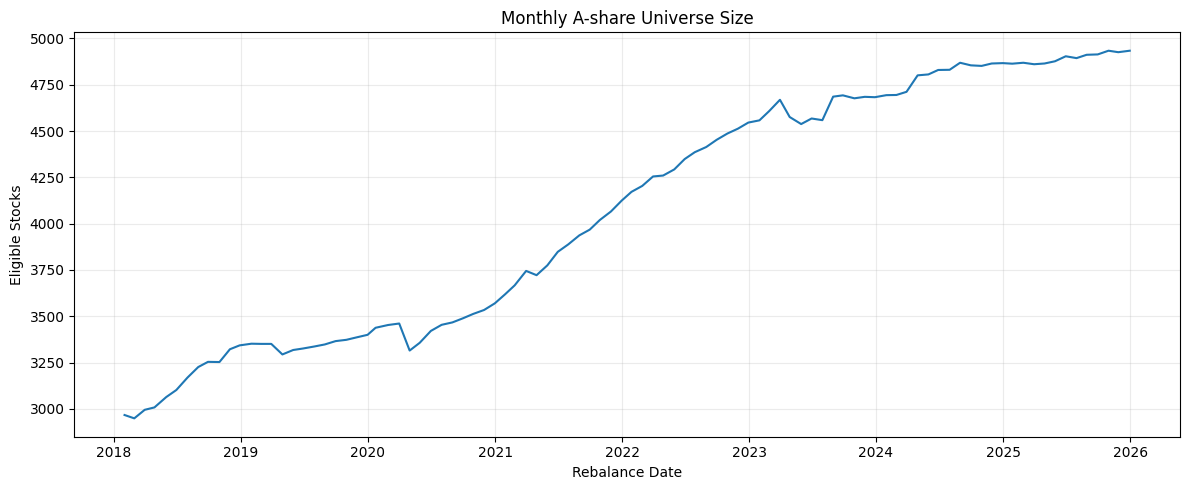

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/universe_size.png


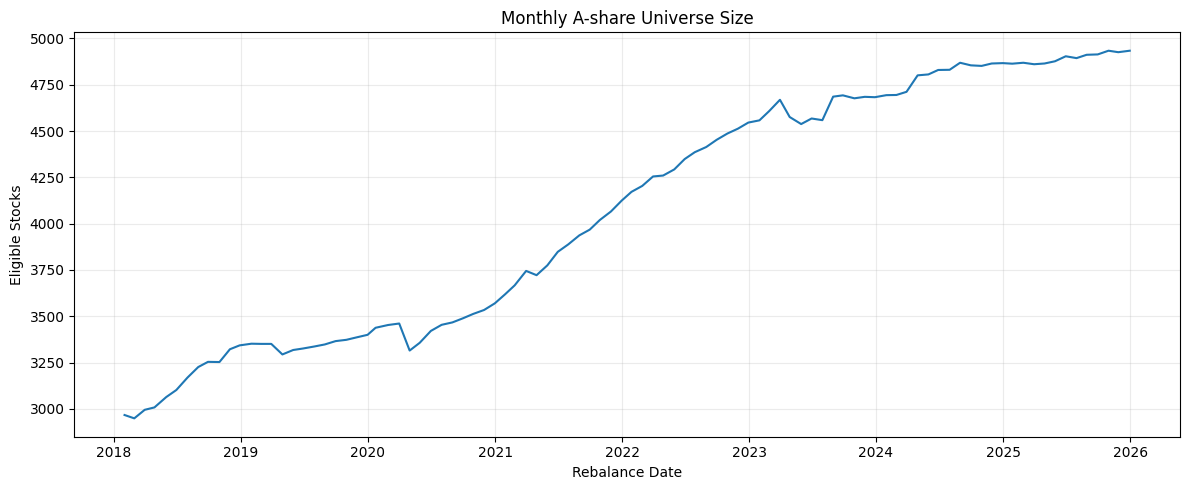

In [15]:
if monthly_summary is None:
    print("没有可绘制的月度股票池汇总数据。")
else:
    figures_directory = PROJECT_ROOT / "figures"
    figures_directory.mkdir(parents=True, exist_ok=True)
    figure_path = figures_directory / "universe_size.png"

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_summary["date"], monthly_summary["最终股票池数量"], linewidth=1.5)
    ax.set_title("Monthly A-share Universe Size")
    ax.set_xlabel("Rebalance Date")
    ax.set_ylabel("Eligible Stocks")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{figure_path}")

## 模块 12：补充图表的公共配置

本模块只为后续新增图表准备 NumPy、百分比坐标格式和中文字体，不修改前面的下载或预处理结果。

In [16]:
import numpy as np
from matplotlib.ticker import PercentFormatter

FIGURES_DIRECTORY = PROJECT_ROOT / "figures"
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

# 优先使用 macOS 常见中文字体，并保留通用字体作为回退。
plt.rcParams["font.sans-serif"] = [
    "PingFang SC",
    "Arial Unicode MS",
    "Heiti TC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

## 模块 13：各行业股票数量分布

为避免把同一股票在不同月份重复计数，本模块使用最新调仓日的合格股票池，展示申万一级行业股票数量。行业为空的股票单独归入“行业缺失”。输出文件为 `figures/industry_distribution.png`。

,stock_count
industry,
机械设备,514
医药生物,453
电子,452
基础化工,393
电力设备,346
计算机,319
汽车,269
轻工制造,148
建筑装饰,139


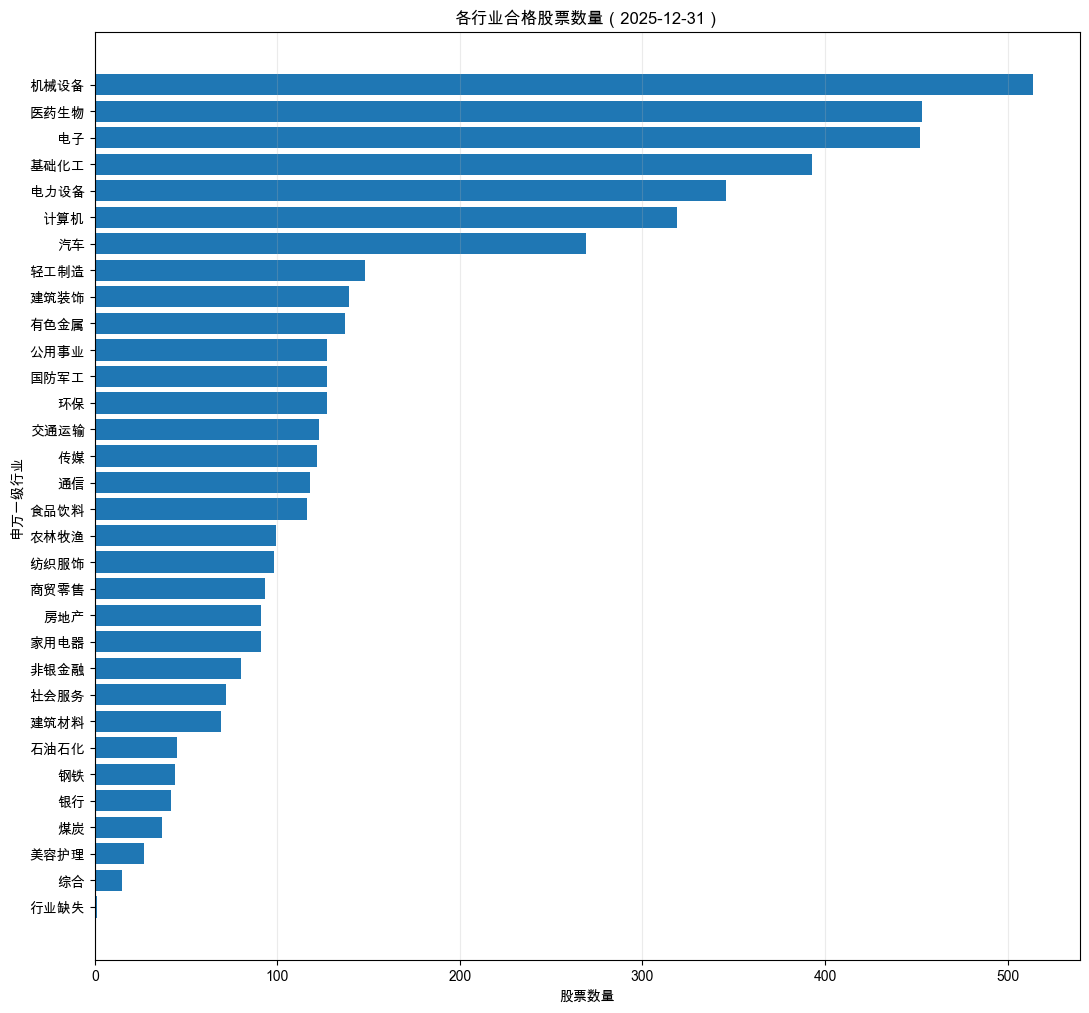

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/industry_distribution.png


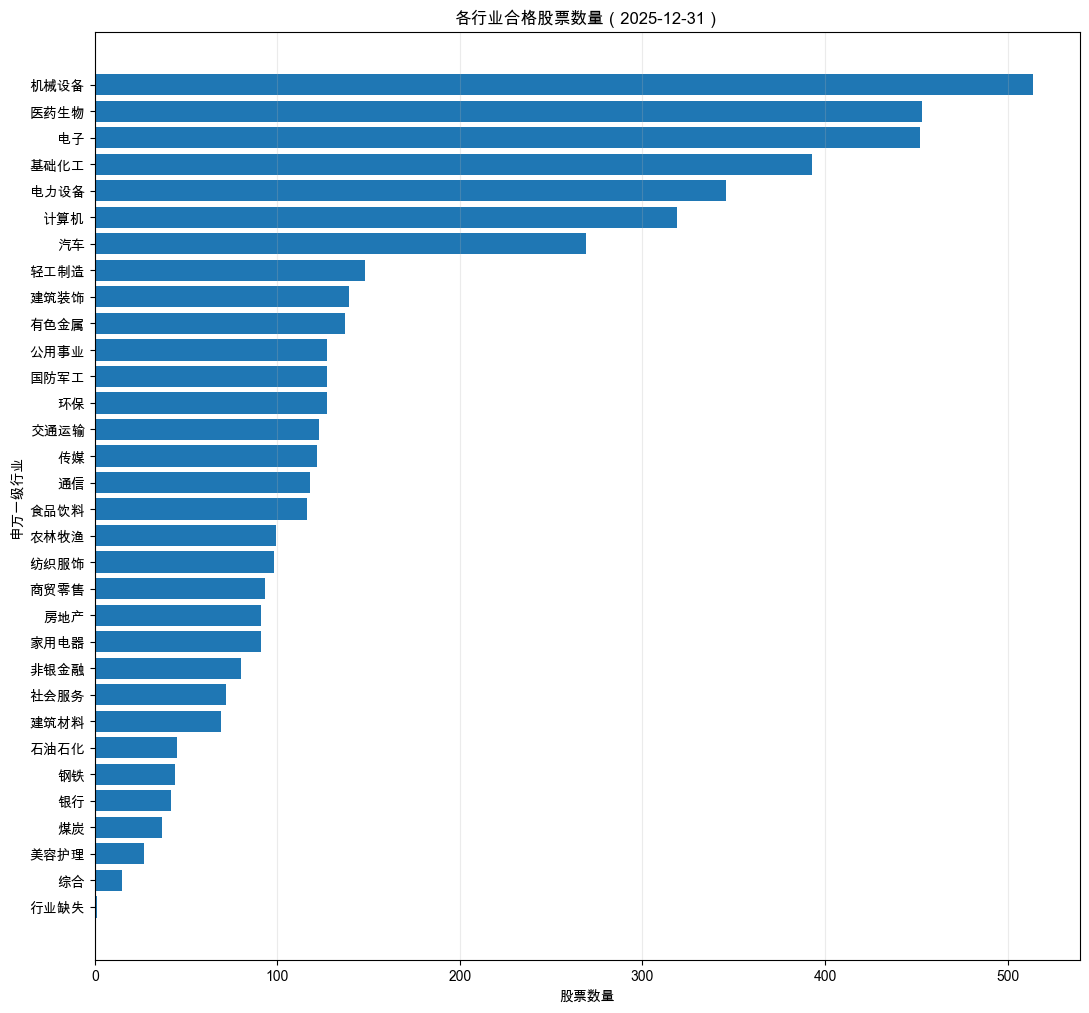

In [17]:
industry_counts = None

eligible_universe = None

if universe_monthly is not None:
    eligible_universe = universe_monthly.loc[
        universe_monthly["is_eligible"].fillna(False)
    ].copy()

if eligible_universe is None or eligible_universe.empty:
    print("没有可用于行业分布分析的合格股票池数据。")
else:
    latest_rebalance_date = eligible_universe["date"].max()
    latest_eligible = eligible_universe.loc[
        eligible_universe["date"].eq(latest_rebalance_date)
    ].copy()
    industry_labels = latest_eligible["industry"].astype("string").fillna("行业缺失")
    industry_counts = (
        industry_labels.value_counts()
        .rename_axis("industry")
        .rename("stock_count")
        .sort_values(ascending=True)
    )

    display(industry_counts.sort_values(ascending=False).to_frame())

    figure_height = max(6, 0.32 * len(industry_counts))
    fig, ax = plt.subplots(figsize=(11, figure_height))
    ax.barh(industry_counts.index, industry_counts.values)
    ax.set_title(f"各行业合格股票数量（{latest_rebalance_date:%Y-%m-%d}）")
    ax.set_xlabel("股票数量")
    ax.set_ylabel("申万一级行业")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()

    industry_figure_path = FIGURES_DIRECTORY / "industry_distribution.png"
    fig.savefig(industry_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{industry_figure_path}")

## 模块 14：市值与 log 市值分布

本模块使用最新调仓日合格股票的总市值。左图展示原始市值并将横轴限制在 99.5% 分位以内，避免少数超大市值股票压缩主体分布；右图对全部正市值取自然对数。输出文件为 `figures/market_cap_distribution.png`。

,market_cap_100m_cny
quantile,
0.00,6.918243
0.01,19.380701
0.05,25.028836
0.25,41.989822
0.50,72.565811
0.75,155.123496
0.95,681.051086
0.99,2384.242505
1.00,28263.016187


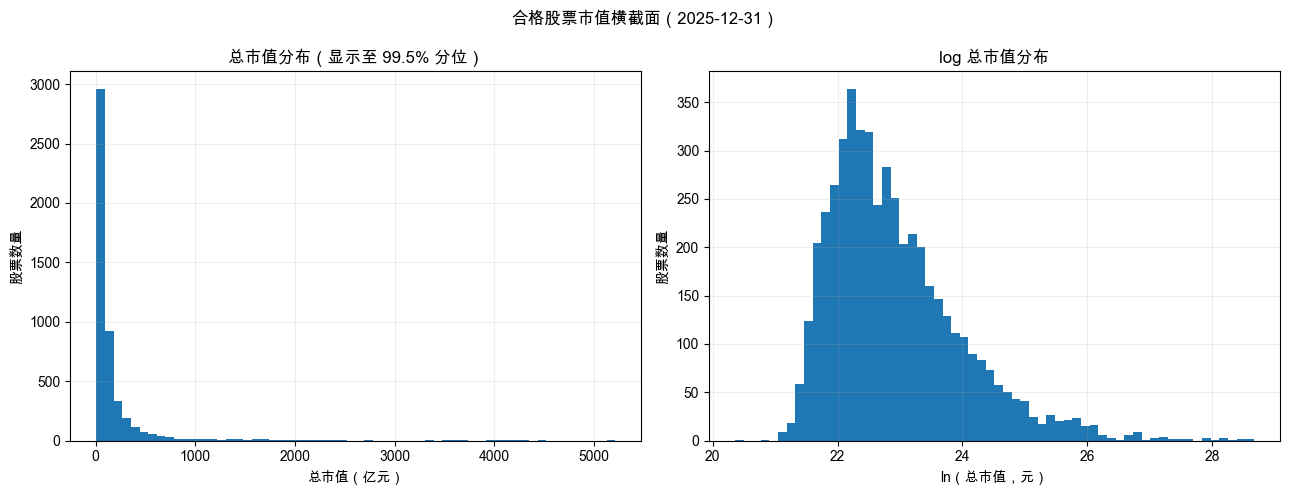

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/market_cap_distribution.png


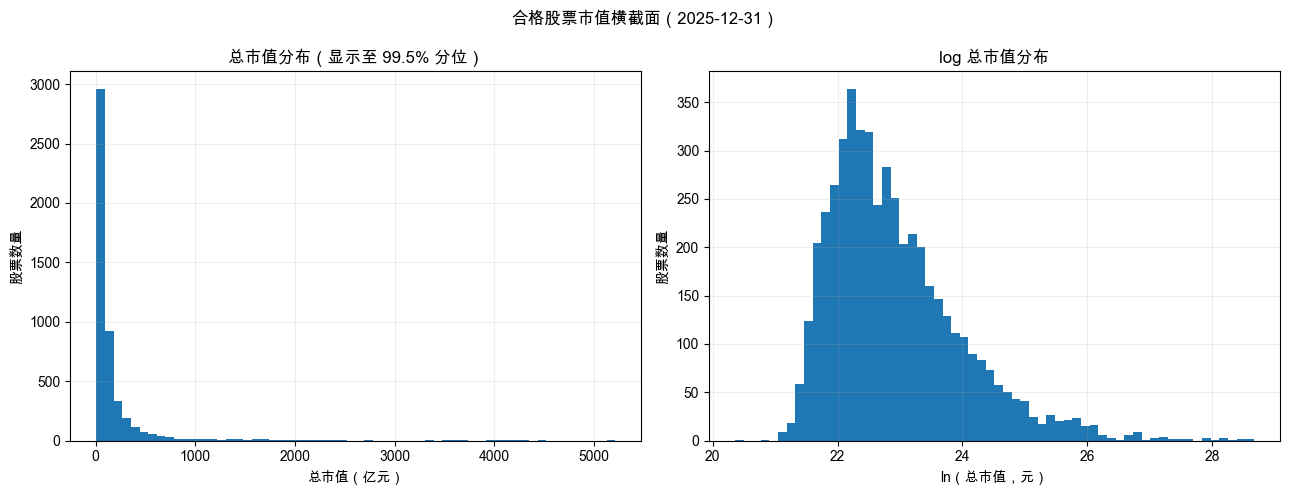

In [18]:
market_cap_distribution = None

if eligible_universe is None or eligible_universe.empty:
    print("没有可用于市值分布分析的合格股票池数据。")
else:
    market_cap_date = eligible_universe["date"].max()
    market_cap = pd.to_numeric(
        eligible_universe.loc[
            eligible_universe["date"].eq(market_cap_date),
            "market_cap",
        ],
        errors="coerce",
    ).dropna()
    market_cap = market_cap.loc[market_cap.gt(0)]
    market_cap_distribution = pd.DataFrame(
        {
            "market_cap_100m_cny": market_cap / 1e8,
            "log_market_cap": np.log(market_cap),
        }
    )

    market_cap_summary = (
        market_cap.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
        .div(1e8)
        .rename("market_cap_100m_cny")
        .to_frame()
    )
    market_cap_summary.index.name = "quantile"
    display(market_cap_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    raw_cap = market_cap_distribution["market_cap_100m_cny"]
    raw_cap_limit = raw_cap.quantile(0.995)
    axes[0].hist(raw_cap.loc[raw_cap.le(raw_cap_limit)], bins=60)
    axes[0].set_title("总市值分布（显示至 99.5% 分位）")
    axes[0].set_xlabel("总市值（亿元）")
    axes[0].set_ylabel("股票数量")

    axes[1].hist(market_cap_distribution["log_market_cap"], bins=60)
    axes[1].set_title("log 总市值分布")
    axes[1].set_xlabel("ln（总市值，元）")
    axes[1].set_ylabel("股票数量")

    for ax in axes:
        ax.grid(alpha=0.2)
    fig.suptitle(f"合格股票市值横截面（{market_cap_date:%Y-%m-%d}）")
    fig.tight_layout()

    market_cap_figure_path = FIGURES_DIRECTORY / "market_cap_distribution.png"
    fig.savefig(market_cap_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{market_cap_figure_path}")

## 模块 15：每日与每月缺失率

每日缺失率按 `price_daily` 的行情、复权、市值和涨跌停核心字段计算。月度部分把 `has_price_record == False` 作为结构性无行情单独统计，并只在有月末行情的记录中计算行业、市值和财务字段缺失率，避免把停牌等导致的无行情与字段缺失混为一谈。银行和非银金融不适用普通毛利润口径，后续 GP 因子应使用 `has_gp_factor_data` 单独筛选，不应把其毛利润缺失填成零。输出文件为 `figures/missing_rate.png`。

,dataset,field,missing_rate_percent
9,price_daily,up_limit_price,0.007634
10,price_daily,down_limit_price,0.007634
8,price_daily,market_cap,0.000140
0,price_daily,open,0.000000
1,price_daily,high,0.000000
2,price_daily,low,0.000000
3,price_daily,close,0.000000
4,price_daily,prev_close,0.000000
5,price_daily,volume,0.000000
6,price_daily,amount,0.000000


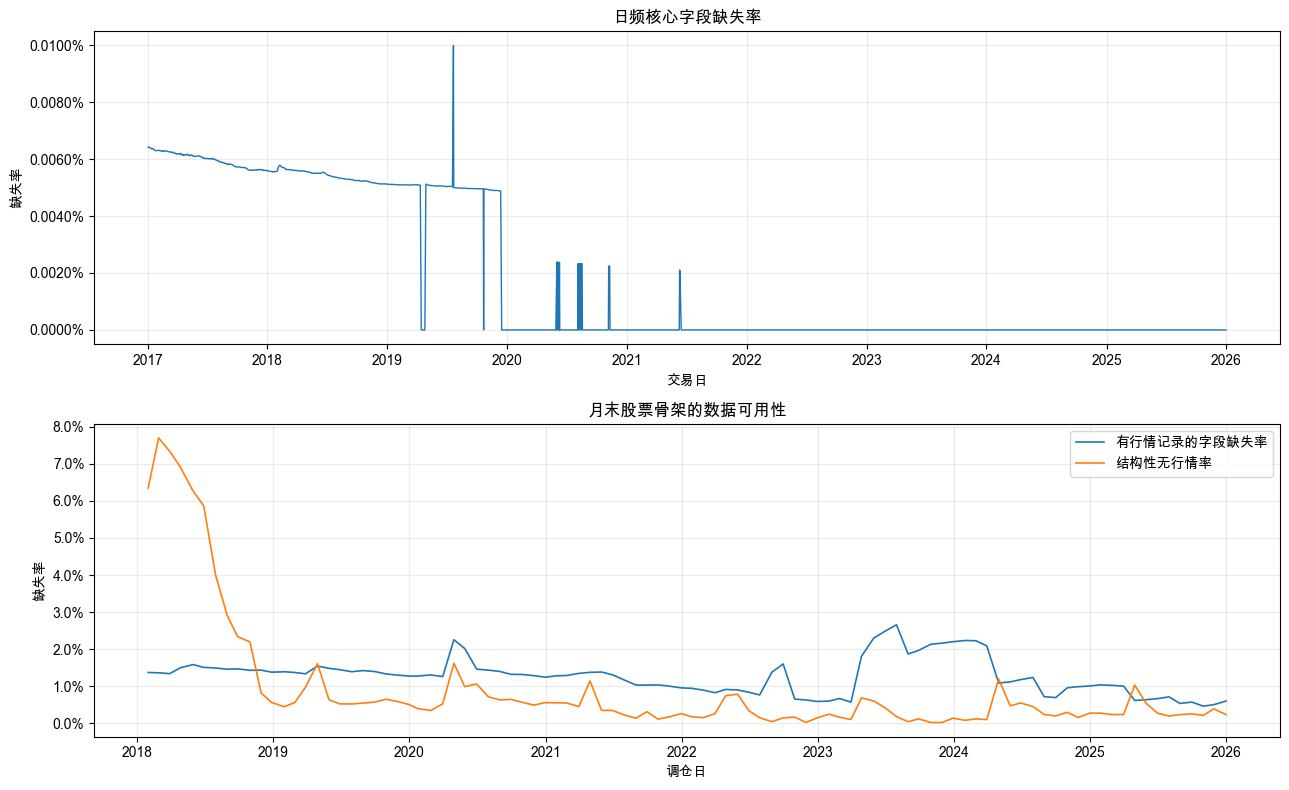

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/missing_rate.png


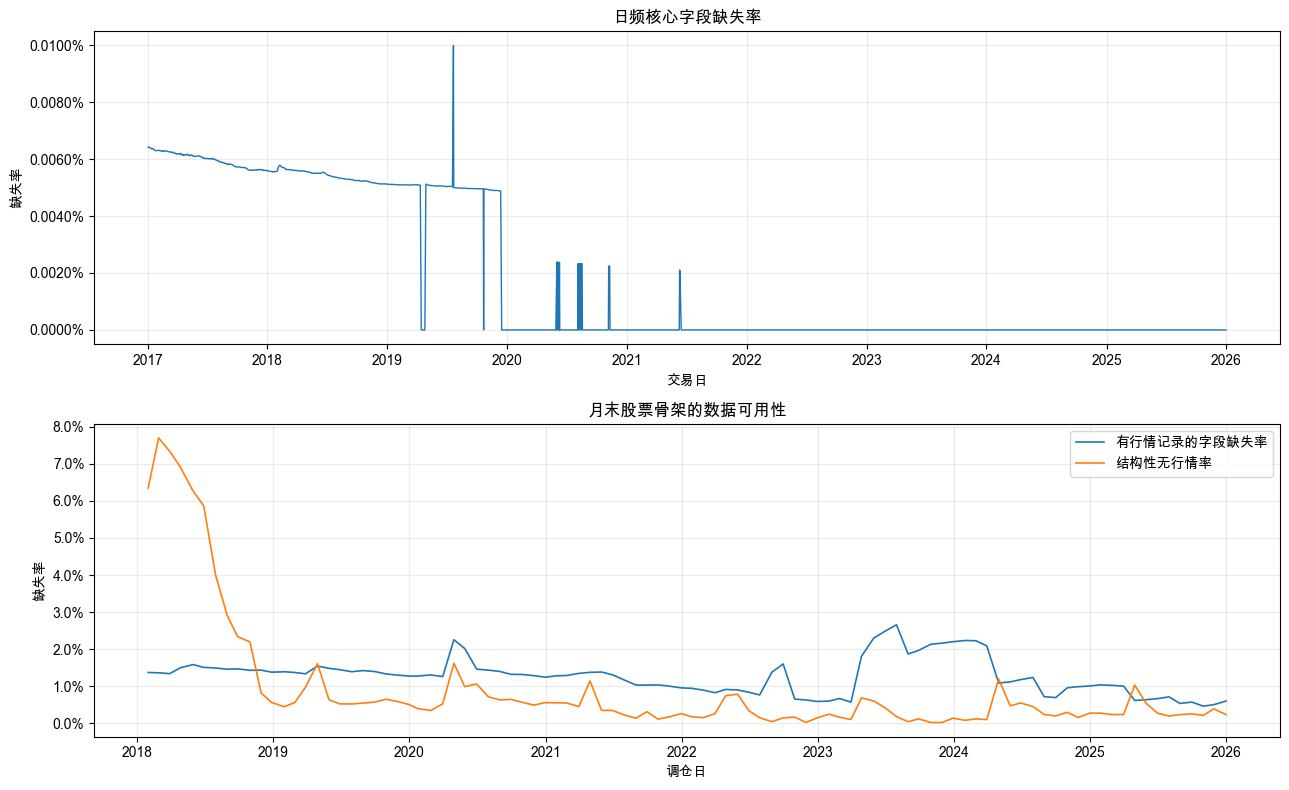

In [19]:
daily_missing_rate = None
monthly_missing_rate = None
monthly_no_price_rate = None

if price_daily is None or universe_monthly is None:
    print("没有完整加载 price_daily 和 universe_monthly，无法计算缺失率。")
else:
    requested_daily_fields = [
        "open", "high", "low", "close", "prev_close",
        "volume", "amount", "adj_factor", "market_cap",
        "up_limit_price", "down_limit_price",
    ]
    requested_monthly_fields = [
        "industry", "market_cap", "total_assets", "total_equity",
        "net_profit_ttm", "revenue_ttm", "gross_profit_ttm",
        "end_date", "announcement_date",
    ]
    daily_fields = [field for field in requested_daily_fields if field in price_daily.columns]
    monthly_fields = [
        field for field in requested_monthly_fields if field in universe_monthly.columns
    ]

    missing_daily_fields = sorted(set(requested_daily_fields) - set(daily_fields))
    missing_monthly_fields = sorted(set(requested_monthly_fields) - set(monthly_fields))
    if missing_daily_fields or missing_monthly_fields:
        print(
            f"未参与计算的缺失字段：daily={missing_daily_fields}, "
            f"monthly={missing_monthly_fields}"
        )

    daily_missing_by_field = pd.concat(
        {
            field: price_daily[field].isna().groupby(price_daily["date"]).mean()
            for field in daily_fields
        },
        axis=1,
    ).sort_index()
    monthly_with_price = universe_monthly.loc[
        universe_monthly["has_price_record"].fillna(False)
    ].copy()
    monthly_missing_by_field = pd.concat(
        {
            field: monthly_with_price[field].isna().groupby(monthly_with_price["date"]).mean()
            for field in monthly_fields
        },
        axis=1,
    ).sort_index()

    daily_missing_rate = daily_missing_by_field.mean(axis=1).rename("missing_rate")
    monthly_missing_rate = monthly_missing_by_field.mean(axis=1).rename("missing_rate")
    monthly_no_price_rate = (
        ~universe_monthly["has_price_record"].fillna(False)
    ).groupby(universe_monthly["date"]).mean().rename("no_price_rate")

    missing_by_field = pd.concat(
        [
            price_daily[daily_fields].isna().mean().rename("missing_rate").to_frame()
            .assign(dataset="price_daily"),
            monthly_with_price[monthly_fields].isna().mean().rename("missing_rate").to_frame()
            .assign(dataset="universe_monthly_with_price"),
        ]
    ).reset_index(names="field")
    missing_by_field["missing_rate_percent"] = 100 * missing_by_field["missing_rate"]
    display(
        missing_by_field.sort_values(
            ["dataset", "missing_rate"], ascending=[True, False]
        )[["dataset", "field", "missing_rate_percent"]]
    )

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
    axes[0].plot(daily_missing_rate.index, daily_missing_rate.values, linewidth=1.0)
    axes[0].set_title("日频核心字段缺失率")
    axes[0].set_xlabel("交易日")
    axes[0].set_ylabel("缺失率")
    axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

    axes[1].plot(monthly_missing_rate.index, monthly_missing_rate.values, linewidth=1.2)
    axes[1].plot(
        monthly_no_price_rate.index,
        monthly_no_price_rate.values,
        linewidth=1.2,
        label="结构性无行情率",
    )
    axes[1].lines[0].set_label("有行情记录的字段缺失率")
    axes[1].set_title("月末股票骨架的数据可用性")
    axes[1].set_xlabel("调仓日")
    axes[1].set_ylabel("缺失率")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[1].legend()

    for ax in axes:
        ax.grid(alpha=0.25)
    fig.tight_layout()

    missing_figure_path = FIGURES_DIRECTORY / "missing_rate.png"
    fig.savefig(missing_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{missing_figure_path}")

## 模块 16：收益率极端值分布

本模块使用 `close × adj_factor` 构造复权收盘价，并按股票计算相邻有效行情记录之间的收益率。左图展示 0.1%—99.9% 分位区间，右图统计不同绝对收益阈值的观测数量；同时输出绝对收益最大的记录，便于检查停牌复牌、上市初期或数据异常。输出文件为 `figures/return_extremes.png`。

,return_percent
quantile,
0.000,-96.443089
0.001,-11.924196
0.010,-8.290511
0.050,-4.362075
0.500,0.000000
0.950,4.831833
0.990,10.000000
0.999,19.281777
1.000,488.450276


,date,stock_code,previous_date,gap_calendar_days,close,adj_factor,return_percent,absolute_return_percent
5165625,2022-08-22,000670.SZ,2020-03-19,886.0,13.24,10.0900,488.450276,488.450276
3342273,2020-12-16,000995.SZ,2019-04-25,601.0,31.00,1.6856,314.894850,314.894850
4013010,2021-08-10,000792.SZ,2020-04-29,468.0,35.90,7.3690,306.136154,306.136154
7725519,2024-09-30,301551.SZ,2024-09-27,3.0,181.00,1.0000,257.424961,257.424961
2508725,2020-02-03,688026.SH,2020-01-23,11.0,122.04,1.0000,108.544087,108.544087
3476016,2021-02-01,300939.SZ,2021-01-29,3.0,145.72,1.0000,100.993103,100.993103
7319025,2024-06-05,600766.SH,2024-04-29,37.0,0.35,4.2250,-96.443089,96.443089
7727709,2024-09-30,688615.SH,2024-09-27,3.0,245.01,1.0000,95.992321,95.992321
3471867,2021-01-29,300937.SZ,2021-01-28,1.0,91.00,1.0000,89.583333,89.583333
4904158,2022-06-02,600870.SH,2022-04-29,34.0,0.37,8.2690,-89.577465,89.577465


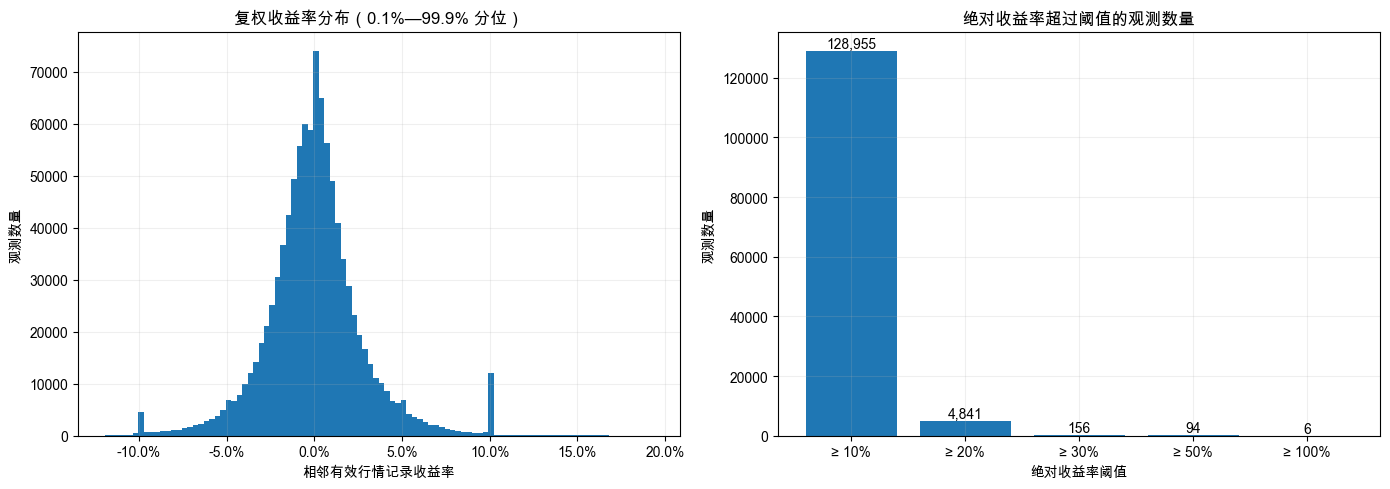

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/return_extremes.png


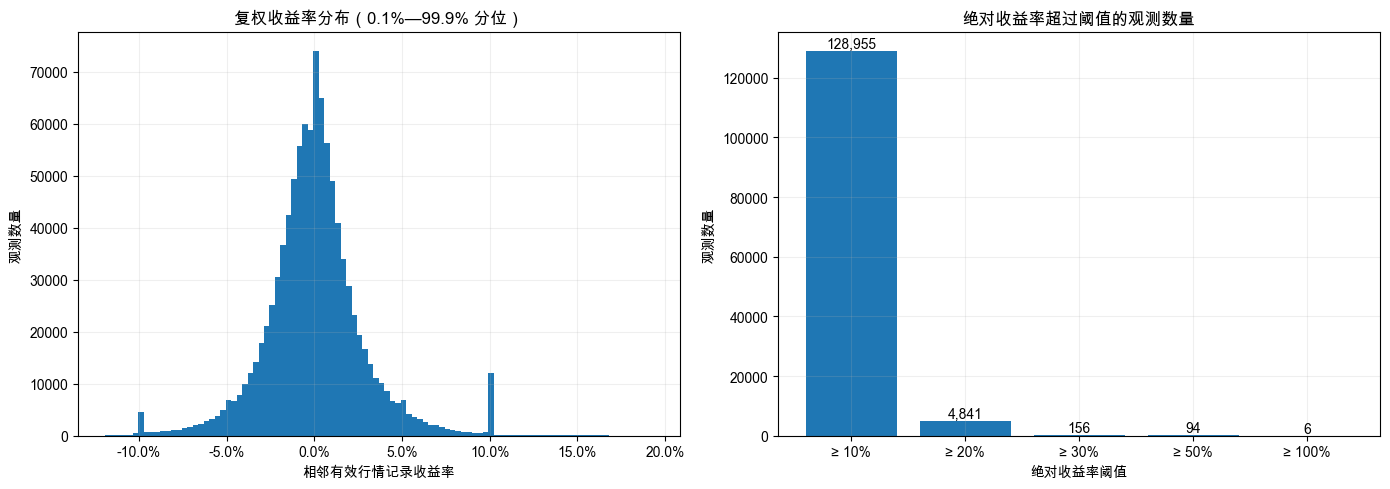

In [20]:
return_observations = None

if price_daily is None:
    print("没有加载 price_daily，无法计算收益率。")
else:
    return_frame = price_daily[["date", "stock_code", "close", "adj_factor"]].copy()
    return_frame["close"] = pd.to_numeric(return_frame["close"], errors="coerce")
    return_frame["adj_factor"] = pd.to_numeric(
        return_frame["adj_factor"], errors="coerce"
    )
    return_frame = return_frame.sort_values(["stock_code", "date"])
    return_frame["adjusted_close"] = return_frame["close"] * return_frame["adj_factor"]
    return_frame["previous_date"] = return_frame.groupby("stock_code")["date"].shift()
    return_frame["return"] = (
        return_frame.groupby("stock_code")["adjusted_close"]
        .pct_change(fill_method=None)
    )
    return_frame["gap_calendar_days"] = (
        return_frame["date"] - return_frame["previous_date"]
    ).dt.days
    return_frame["return"] = return_frame["return"].replace([np.inf, -np.inf], np.nan)
    return_observations = return_frame.dropna(subset=["return"]).copy()
    return_observations["absolute_return"] = return_observations["return"].abs()

    return_quantiles = (
        return_observations["return"]
        .quantile([0, 0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999, 1.00])
        .mul(100)
        .rename("return_percent")
        .to_frame()
    )
    return_quantiles.index.name = "quantile"
    display(return_quantiles)

    extreme_records = return_observations.nlargest(20, "absolute_return")[
        [
            "date", "stock_code", "previous_date", "gap_calendar_days",
            "close", "adj_factor", "return", "absolute_return",
        ]
    ].copy()
    extreme_records["return_percent"] = 100 * extreme_records["return"]
    extreme_records["absolute_return_percent"] = 100 * extreme_records["absolute_return"]
    display(
        extreme_records.drop(columns=["return", "absolute_return"])
    )

    lower_bound, upper_bound = return_observations["return"].quantile([0.001, 0.999])
    central_returns = return_observations.loc[
        return_observations["return"].between(lower_bound, upper_bound),
        "return",
    ]
    if len(central_returns) > 1_000_000:
        central_returns = central_returns.sample(1_000_000, random_state=42)

    thresholds = pd.Series([0.10, 0.20, 0.30, 0.50, 1.00], name="threshold")
    tail_counts = pd.Series(
        {threshold: return_observations["absolute_return"].ge(threshold).sum() for threshold in thresholds}
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(central_returns, bins=100)
    axes[0].set_title("复权收益率分布（0.1%—99.9% 分位）")
    axes[0].set_xlabel("相邻有效行情记录收益率")
    axes[0].set_ylabel("观测数量")
    axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))

    threshold_labels = [f"≥ {threshold:.0%}" for threshold in tail_counts.index]
    axes[1].bar(threshold_labels, tail_counts.values)
    axes[1].set_title("绝对收益率超过阈值的观测数量")
    axes[1].set_xlabel("绝对收益率阈值")
    axes[1].set_ylabel("观测数量")
    for position, count in enumerate(tail_counts.values):
        axes[1].text(position, count, f"{count:,}", ha="center", va="bottom")

    for ax in axes:
        ax.grid(alpha=0.2)
    fig.tight_layout()

    return_figure_path = FIGURES_DIRECTORY / "return_extremes.png"
    fig.savefig(return_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{return_figure_path}")

## 模块 17：已失效的数据质量评估（历史记录）

> 以下静态文字和数值对应旧版月度股票池及财报处理结果，不属于当前工作流的有效输出。月度股票骨架和财报版本逻辑均已改变；重新运行预处理和绘图模块后，应根据新输出重写本节。

总体判断：沪深范围过滤正确，行情数据质量较高，行业和市值覆盖良好；但财务报表“修订版本”的处理存在潜在未来信息问题。当前数据适合继续开发和诊断，但修复财报版本逻辑前，不建议直接用于正式因子检验和回测。

## 1. 覆盖范围与结构

处理后数据：

| 数据集 | 规模 | 时间范围 | 交易日/月数 |
|---|---:|---|---:|
| `price_daily` | 9,286,960 行，5,406 只股票 | 2017-01-03—2025-12-31 | 2,186 个交易日 |
| `universe_monthly` | 423,069 行，5,402 只股票 | 2018-01-31—2025-12-31 | 96 个调仓月 |

检查结果：

- 只有 `.SH` 和 `.SZ`，BJ 为 0。
- 日频和月频主键均无重复。
- 股票代码、日期均无空值。
- 日频日期完整覆盖交易日历中的全部 2,186 个开市日。
- 没有上市前或退市后的合格股票记录。

这一部分质量很好。

## 2. 股票池规模

[universe_size.png](/Users/mac/Desktop/a-share-multifactor/figures/universe_size.png)

合格股票从 2018 年初约 2,900 只，增长到 2025 年底 4,932 只，长期走势符合沪深上市公司数量扩张。

具体范围：

- 最少：2,891 只，2018-02-28。
- 最新：4,932 只，2025-12-31。
- 最新月末候选股票 5,171 只，最终合格率 95.38%。

最新截面的主要剔除原因是：

- ST：174 只。
- 核心财务字段缺失：56 只。
- 上市不足 120 个交易日：43 只。
- 一字涨停等无法正常买入：5 只。
- 停牌：1 只。

这些原因可能重叠，不能直接相加。

需要注意，2018-08、2023-08、2024-04 分别出现约 `+153`、`+107`、`+94` 的阶跃。检查表明这些变化主要来自财报字段由缺失变为可用，而不是突然大量上市。这种“财报季样本扩张”本身可能合理，但后续比较跨期因子表现时要注意样本构成变化。

## 3. 行业覆盖

[industry_distribution.png](/Users/mac/Desktop/a-share-multifactor/figures/industry_distribution.png)

最新 4,932 只合格股票中：

- 4,931 只有申万一级行业。
- 只有 1 只缺失行业，覆盖率约 99.98%。
- 缺失股票为 `002310.SZ`。
- 行业分布广泛，机械设备、医药生物、电子、基础化工占比较高，符合沪深市场结构。

原始行业区间还满足：

- 没有重复行业区间。
- 没有相互重叠的行业有效期。

所以行业数据整体质量很好。唯一缺失记录可以在行业中性化前单独排除或归入“未知行业”。

## 4. 市值数据

[market_cap_distribution.png](/Users/mac/Desktop/a-share-multifactor/figures/market_cap_distribution.png)

最新合格股票市值分位数：

| 分位数 | 总市值 |
|---:|---:|
| 最小值 | 6.92 亿元 |
| 1% | 19.38 亿元 |
| 5% | 25.02 亿元 |
| 中位数 | 72.57 亿元 |
| 95% | 681.39 亿元 |
| 99% | 2,385.22 亿元 |
| 最大值 | 2.83 万亿元 |

原始市值明显右偏，取 log 后接近单峰长尾分布，属于典型股票市值横截面形态。没有发现零市值、负市值或异常数量级。

当前 `liquidity_quantile=None`，尚未启用低流动性过滤。这不是数据质量问题，但正式回测时应启用流动性约束，或者充分计入冲击成本。

## 5. 缺失率

[missing_rate.png](/Users/mac/Desktop/a-share-multifactor/figures/missing_rate.png)

日频行情质量很高：

- OHLC、成交量、成交额、复权因子没有缺失。
- 涨跌停价格整体缺失率约 0.0076%。
- 市值缺失率约 0.00014%。
- 图中最高的日均核心字段缺失率也只有约 0.01%。

月末候选股票九个字段的平均缺失率：

- 中位数约 0.80%。
- 最大约 2.46%，出现在样本早期。
- 最新约 0.61%。

最新候选股票中，核心字段存在缺失的有 56/5,171，只占 1.08%，并已被 `has_core_data` 排除。

但有一个需要单独处理的问题：`gross_profit_ttm` 没有包含在当前核心字段检查中，[preprocess.py:524](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:524)。因此最新合格池仍有 113 只股票缺少毛利润，占 2.29%。

其中：

- 非银金融：59 只。
- 银行：42 只。
- 其他行业：12 只。

银行和非银金融缺少传统营业成本、毛利润具有会计口径上的合理性。由于 README 的 GP 质量因子使用 `gross_profit_ttm / total_assets`，建议采用因子级缺失过滤，并考虑在 GP 因子检验中排除金融行业；不要将缺失毛利润填成零。

## 6. 收益率极端值

[return_extremes.png](/Users/mac/Desktop/a-share-multifactor/figures/return_extremes.png)

排除 BJ 后，极端值明显恢复正常：

| 绝对收益率阈值 | 记录数 |
|---:|---:|
| ≥10% | 128,955 |
| ≥20% | 4,841 |
| ≥30% | 156 |
| ≥50% | 94 |
| ≥100% | 6 |

约 ±10% 和 +20% 附近的堆积符合主板、创业板和科创板的涨跌幅限制，不像数据错误。

6 条超过 100% 的记录也可以解释：

- 3 条发生在长时间停牌复牌后，间隔 468—886 天。
- 3 条发生在新股上市初期无涨跌幅限制阶段。

因此它们未必是错误数据。不过图中收益率定义是“相邻有效行情记录收益率”，长时间停牌后的累计变化不能解释为普通单日收益。构造未来收益、动量和波动率时，应区分：

- 相邻市场交易日收益。
- 停牌跨期收益。
- 新股上市初期无涨跌幅限制收益。

## 7. 最重要的问题：财报修订版本

当前最大的风险不在五张图的表面缺失率，而在财务报表版本处理。

[_deduplicate_reports()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:209) 对每只股票、每个报告期排序后直接保留最后一次修订版：

```python
reports.drop_duplicates(["ts_code", "end_date"], keep="last")
```

这会造成两个问题：

1. 原始公告版本被后来的修订版本覆盖，历史时点可能错误地表现为“没有财报”。
2. TTM 使用的上年年报或上年同期值可能来自之后才发布的修订版，但 TTM 的可用日期没有同步推迟，形成潜在未来信息。

例如 `002726.SZ` 的原始数据包含 2025-10-31 已发布的三季报，但也包含 2026 年修订版本。当前代码保留修订版，导致 2025-12-31 的处理结果仍沿用 2020 年财报。

量化检查发现：

- 6,537 个 TTM 报告记录包含“晚于当前报告公告日才发布的历史修订组件”。
- 约 11,008 条合格月度记录可能受到影响，占合格记录的 2.79%，涉及 736 只股票。
- 最新截面有 85 只合格股票的财报公告已超过 180 天，9 只超过 365 天。

所以，当前代码没有简单地把未来报表直接匹配到过去，但可能把未来修订后的历史数值用于早期 TTM 计算，同时造成虚假缺失和财报过旧。正式研究前应优先修复：

1. 保留同一报告期的所有公告/修订版本。
2. 每个调仓日只选择 `announcement_date <= 调仓日` 的最新版本。
3. TTM 三个组成部分的可用日期取三者公告日期最大值。
4. 增加财报新鲜度检查，防止多年以前的财报仍通过 `has_core_data`。

结论是：行情、交易日历、市值、行业和股票范围已经达到较高质量；财务原始数据也比较完整，但财报版本预处理尚未达到严格 point-in-time 回测要求。这应当是进入 Notebook 02/03 前的最高优先级修正项。

这里的 point-in-time 匹配原则是：

> 在调仓日 \(t\)，只能使用公告日期不晚于 \(t\) 的财报版本；后来发布的修订版只能影响修订日之后的调仓。

整体调用链是：

```text
prepare_report_versions
→ select_latest_report_versions_as_of
→ _calculate_financial_snapshot_as_of
→ build_monthly_financial_snapshots
→ build_monthly_universe
```

### (1) 保留全部财报版本

[prepare_report_versions()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:214) 负责清理原始利润表和资产负债表。

它先构造版本的真实可用日期：

```python
reports["announcement_date"] = reports["f_ann_date"].fillna(
    reports["ann_date"]
)
```

然后只删除以下三个字段完全相同的重复记录：

```python
[
    "ts_code",
    "end_date",
    "announcement_date",
]
```

含义分别是：

- `ts_code`：股票；
-- `end_date`：财报报告期；
- `announcement_date`：该报表版本何时公开公布。

同一个报告期的不同公告版本不会被日期不同，因此都会被保留。

例如：

| 报告期 | 公告日期 | 版本 |
|---|---|---|
| 2023-12-31 | 2024-03-20 | 原始年报版 |
| 2023-12-31 | 2026-01-31 | 修订版 |

旧版不会覆盖原始版。

### (2) 在每个调仓日选择当时可见的版本

[select_latest_report_versions_as_of()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:278) 接收一个具体调仓日：

```python
available = report_versions.loc[
    report_versions["announcement_date"].le(as_of_date)
    & report_versions["end_date"].le(as_of_date)
]
```

先执行两个限制：

- 公告日不能晚于调仓日；
- 报告期不能晚于调仓日。

然后才对每只股票、每个报告期保留当时的最新版本：

```python
available.sort_values(
    ["ts_code", "end_date", "announcement_date"]
).drop_duplicates(
    ["ts_code", "end_date"],
    keep="last",
)
```

以前的错误是“先在全样本选最终版本，再匹配历史”；现在变成“先截断到仓日之后的数据，再从可见版本中选最新版本”。

例如：

| 调仓日 | 可使用版本 |
|---|---|
| 2025-12-31 | 2024-03-20 原始版 |
| 2026-02-28 | 2026-01-31 修订版 |

### (3) 使用同一时点可见的数据计算 TTM

[_calculate_financial_snapshot_as_of()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:318) 使用已经经过日期截断的财报计算 TTM。

对于非年报：

```text
TTM
= 当期累计值
+ 上年年报值
- 上年同期累计值
```

例如计算 2024Q3 的 TTM 营业收入：

```text
2024Q3 累计营业收入
+ 2023 年报营业收入
- 2023Q3 累计营业收入
```

函数会对以下三个利润表字段分别计算：

```python
values = [
    "revenue",
    "oper_cost",
    "n_income_attr_p",
]
```

从而得到：

- `revenue_ttm`
- `oper_cost_ttm`
- `net_profit_ttm`

毛利润随后计算为：

```python
gross_profit_ttm = revenue_ttm - oper_cost_ttm
```

因为当期、上年年报和上年同期都来自“截至调仓日可见的版本”，所以不会在 2025 年使用 2026 年才发布的修订值。

对于年报，TTM 直接等于该年度累计值，不再组合上年数据。

### (4) 记录每个组成部分的公告日

为了能够审计，快照中保留了：

```text
current_income_announcement_date
prior_same_announcement_date
prior_annual_announcement_date
balance_announcement_date
```

分别对应：

- 当期利润表公告日；
- 上年同期利润表公告日；
- 上年年报公告日；
- 当期资产负债表公告日。

最终财务指标的整体可用日期取这些日期的最大值：

```python
snapshot["financial_available_date"] = snapshot[
    availability_columns
].max(axis=1)
```

原因是只有最后一个组成部分公布后，完整财务指标才真正可计算。

为了兼容原有 Notebook，代码同时令：

```python
announcement_date = financial_available_date
```

如果某个 TTM 组成部分不存在，指标会保持缺失，不会自动回退到多年以前的完整财报。

### (5) 为每个调仓月单独生成快照

[build_monthly_financial_snapshots()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:430) 遍历所有月末调仓日：

```python
for as_of_date in dates:
    income_as_of = select_latest_report_versions_as_of(
        income_versions,
        as_of_date,
    )
    balance_as_of = select_latest_report_versions_as_of(
        balance_versions,
        as_of_date,
    )

    snapshot = _calculate_financial_snapshot_as_of(
        income_as_of,
        balance_as_of,
        as_of_date,
    )
```

因此，同一只股票在不同月份可以对应不同版本：

```text
2025-12 月快照 → 原始版
2026-01 月快照 → 新修订版
```

历史月份不会因以后重新运行程序而被最终修订版回填。

函数最后执行两个强制检查：

```python
if panel.duplicated(["date", "stock_code"]).any():
    raise ValueError(...)

if panel["financial_available_date"].gt(panel["date"]).any():
    raise ValueError(...)
```

也就是保证：

- 每个调仓日、每只股票只有一条财务快照；
- 财务数据的可用日期不能晚于调仓日。

### (6) 与月末行情精确合并

[build_monthly_universe()](/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:553) 不再使用旧的 `merge_asof` 重新猜测财报，而是直接按照：

```python
monthly = monthly.merge(
    financial_snapshots,
    on=["stock_code", "date"],
    how="left",
    validate="one_to_one",
)
```

因为 `financial_snapshots` 已经是“股票 × 调仓日”的 point-in-time 快照。

合并后还会再次检查：

```python
future_financials = monthly[
    "financial_available_date"
].gt(monthly["date"])
```

只要发现未来财务数据，就立即报错而不是继续生成股票池。

### (7) 输出审计字段

最终的 `universe_monthly` 会保留：

```text
end_date
financial_available_date
current_income_announcement_date
prior_same_announcement_date
prior_annual_announcement_date
balance_announcement_date
report_age_days
announcement_age_days
```

可以这样检查某只股票：

```python
columns = [
    "date",
    "stock_code",
    "end_date",
    "current_income_announcement_date",
    "prior_same_announcement_date",
    "prior_annual_announcement_date",
    "balance_announcement_date",
    "financial_available_date",
    "report_age_days",
]

display(
    universe_monthly.loc[
        universe_monthly["stock_code"].eq("002726.SZ"),
        columns,
    ].tail(12)
)
```

全局检查：

```python
assert not (
    universe_monthly["financial_available_date"]
    > universe_monthly["date"]
).any()
```

修复后的真实数据测试中，`002726.SZ` 在 2025-12-31 已正确匹配到：

```text
报告期：2025-09-30
财务可得日：2025-10-31
```

而不是原先错误沿用的 2020 年财报。

## 18. 预览数据

In [21]:
df = pd.read_parquet("/Users/mac/Desktop/a-share-multifactor/data/processed/universe_monthly.parquet")

df.columns

Index(['date', 'stock_code', 'list_date', 'delist_date', 'is_listed', 'open',
       'high', 'low', 'close', 'prev_close', 'volume', 'amount', 'adj_factor',
       'market_cap', 'limit_status', 'up_limit_price', 'down_limit_price',
       'is_limit_up_close', 'is_limit_down_close', 'is_one_price_limit_up',
       'is_one_price_limit_down', 'has_price_record', 'listing_trading_days',
       'is_st', 'is_suspended', 'end_date', 'announcement_date',
       'financial_available_date', 'current_income_announcement_date',
       'prior_same_announcement_date', 'prior_annual_announcement_date',
       'balance_announcement_date', 'revenue_ttm', 'net_profit_ttm',
       'gross_profit_ttm', 'total_assets', 'total_equity', 'industry',
       'report_age_days', 'announcement_age_days',
       'is_gross_profit_applicable', 'has_gross_profit_data',
       'has_gp_factor_data', 'has_core_data', 'is_buyable',
       'passes_listing_age', 'passes_liquidity', 'is_eligible'],
      dtype='object')

In [22]:
df.loc[df["date"]=="2022-04-29", ["stock_code", "close"]]

,stock_code,close
200007,000001.SZ,15.32
200008,000002.SZ,19.38
200009,000004.SZ,12.58
200010,000005.SZ,1.86
200011,000006.SZ,4.36
...,...,...
204716,688799.SH,30.61
204717,688800.SH,97.80
204718,688819.SH,25.39
204719,688981.SH,39.72
